In [1]:
from utils.utils_ml import *

In [2]:
features_memmap = np.load('features_extracted_and_selected_8_sim.npy', mmap_mode='r')

old_label_arr = np.array([np.tile(i,3000) for i in np.arange(0,8)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

new_label_arr = convert_labels(old_label_arr, class_to_poles)

X_train, X_test, y_train, y_test = train_test_split(features_memmap, new_label_arr, test_size=0.1, random_state=42)

In [3]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
models = []
preds = []
data_uncertainty = []
knowledge_uncertainty = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train, y_train[:, i])
    val_pool = Pool(X_test, y_test[:, i])

    # model = CatBoostRegressor(
    #     iterations=2000,
    #     depth=10,
    #     learning_rate=0.1,
    #     loss_function='RMSEWithUncertainty',
    #     subsample=0.5,
    #     bootstrap_type='Bernoulli',
    #     random_seed=0,
    #     verbose=100,
    #     # early_stopping_rounds=1000
    # )
    model = CatBoostRegressor(
    iterations=1000,             # Reduce iterations
    depth=9,                     # Shallower trees to reduce complexity
    learning_rate=0.03,          # Smaller learning rate for gradual training
    loss_function='RMSEWithUncertainty',
    subsample=0.8,               # Use more of the data in each iteration
    bootstrap_type='Bernoulli',
    random_seed=0,
    verbose=100,
    l2_leaf_reg=10,              # Add L2 regularization
    early_stopping_rounds=10    # Stop early if no improvement
)
    model.fit(train_pool, eval_set=val_pool, use_best_model=False)
    models.append(model)

    # Generate predictions with uncertainty
    pred = model.virtual_ensembles_predict(X_test, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds.append(pred[:, 0])  # Mean predictions
    data_uncertainty.append(pred[:, 2])  # Data uncertainty
    knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds = np.column_stack(preds)
data_uncertainty = np.column_stack(data_uncertainty)
knowledge_uncertainty = np.column_stack(knowledge_uncertainty)

0:	learn: 0.6706259	test: 0.6594422	best: 0.6594422 (0)	total: 589ms	remaining: 9m 48s
100:	learn: -0.9791845	test: -0.9746477	best: -0.9746477 (100)	total: 50.7s	remaining: 7m 31s
200:	learn: -1.8461878	test: -1.7945696	best: -1.7945899 (199)	total: 1m 41s	remaining: 6m 41s
300:	learn: -2.0017478	test: -1.9091361	best: -1.9161747 (294)	total: 2m 31s	remaining: 5m 52s
Stopped by overfitting detector  (10 iterations wait)

bestTest = -1.964640049
bestIteration = 357

0:	learn: 0.8447035	test: 0.8384969	best: 0.8384969 (0)	total: 501ms	remaining: 8m 20s
100:	learn: -0.7744542	test: -0.7277626	best: -0.7277626 (100)	total: 51.4s	remaining: 7m 37s
200:	learn: -1.3693477	test: -1.2514595	best: -1.2514595 (200)	total: 1m 42s	remaining: 6m 47s
300:	learn: -1.5641439	test: -1.4005694	best: -1.4005694 (300)	total: 2m 32s	remaining: 5m 55s
400:	learn: -1.7161051	test: -1.5062040	best: -1.5062040 (400)	total: 3m 25s	remaining: 5m 6s
Stopped by overfitting detector  (10 iterations wait)

bestTest 

In [ ]:
# search_hyp = False
# if search_hyp:

#     # Train Pool for CatBoost (multi-output regression requires separate models per target)
#     models = []
#     preds = []
#     data_uncertainty = []
#     knowledge_uncertainty = []

#     param_grid = {
#         'iterations': [500, 1000, 1500],
#         'learning_rate': [0.01, 0.1, 0.2],
#         'depth': [6, 8, 10],
#         'subsample': [0.5, 0.7, 1.0],
#         'bootstrap_type': ['Bernoulli']
#     }

#     # cv = KFold(n_splits=5, shuffle=True, random_state=0)


#     for i in range(y_train.shape[1]):
#         train_pool = Pool(X_train, y_train[:, i])
#         val_pool = Pool(X_test, y_test[:, i])

#         model = CatBoostRegressor(
#             loss_function='RMSEWithUncertainty',
#             random_seed=0,
#             verbose=100
#             )
        
#         cv_results = model.grid_search(param_grid,
#                     X=train_pool,
#                     cv=2,
#                     partition_random_seed=0,
#                     calc_cv_statistics=True,
#                     search_by_train_test_split=True,
#                     refit=True,
#                     shuffle=True,
#                     stratified=None,
#                     train_size=0.8,
#                     verbose=True,
#                     plot=True)

#         # Generate predictions with uncertainty
#         pred = model.virtual_ensembles_predict(X_test, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#         preds.append(pred[:, 0])  # Mean predictions
#         data_uncertainty.append(pred[:, 2])  # Data uncertainty
#         knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty
         

#     # Convert lists to arrays for easier manipulation
#     preds = np.column_stack(preds)
#     data_uncertainty = np.column_stack(data_uncertainty)
#     knowledge_uncertainty = np.column_stack(knowledge_uncertainty)



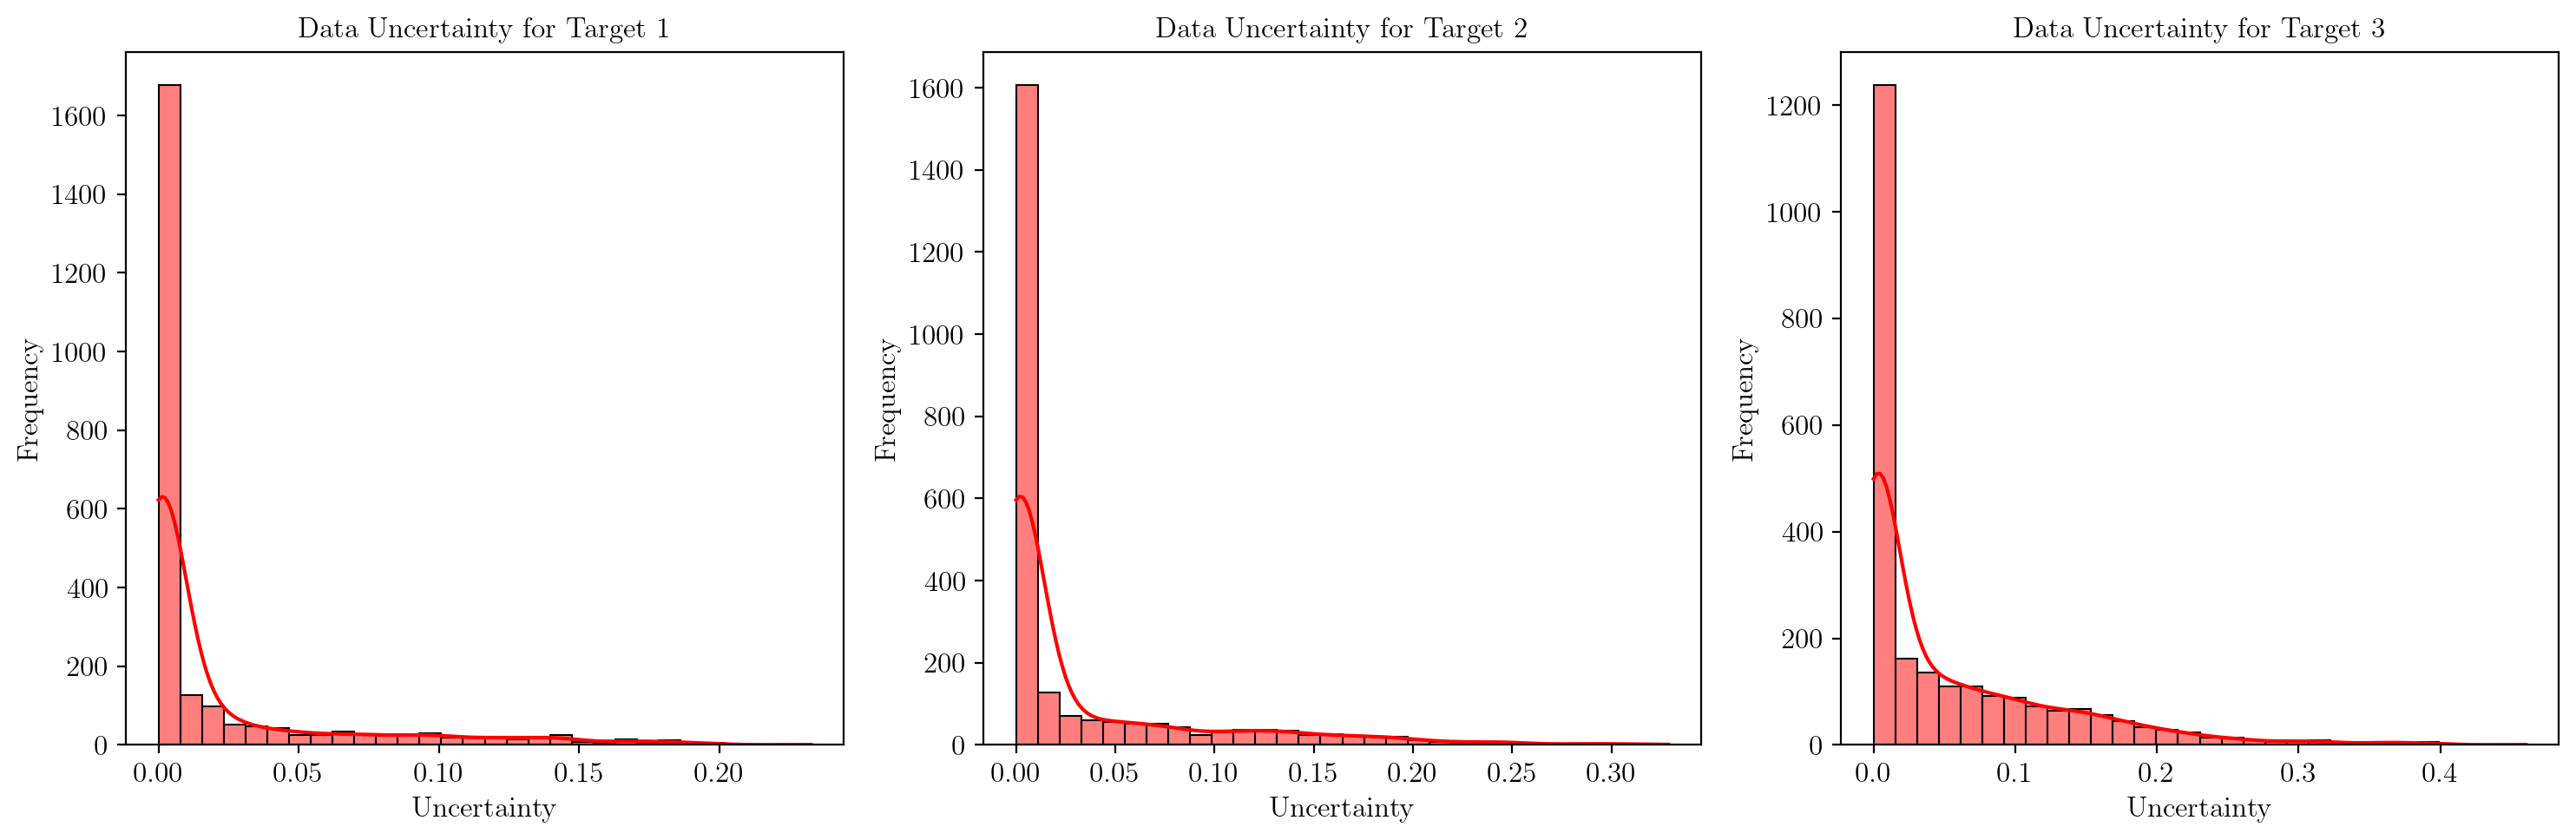

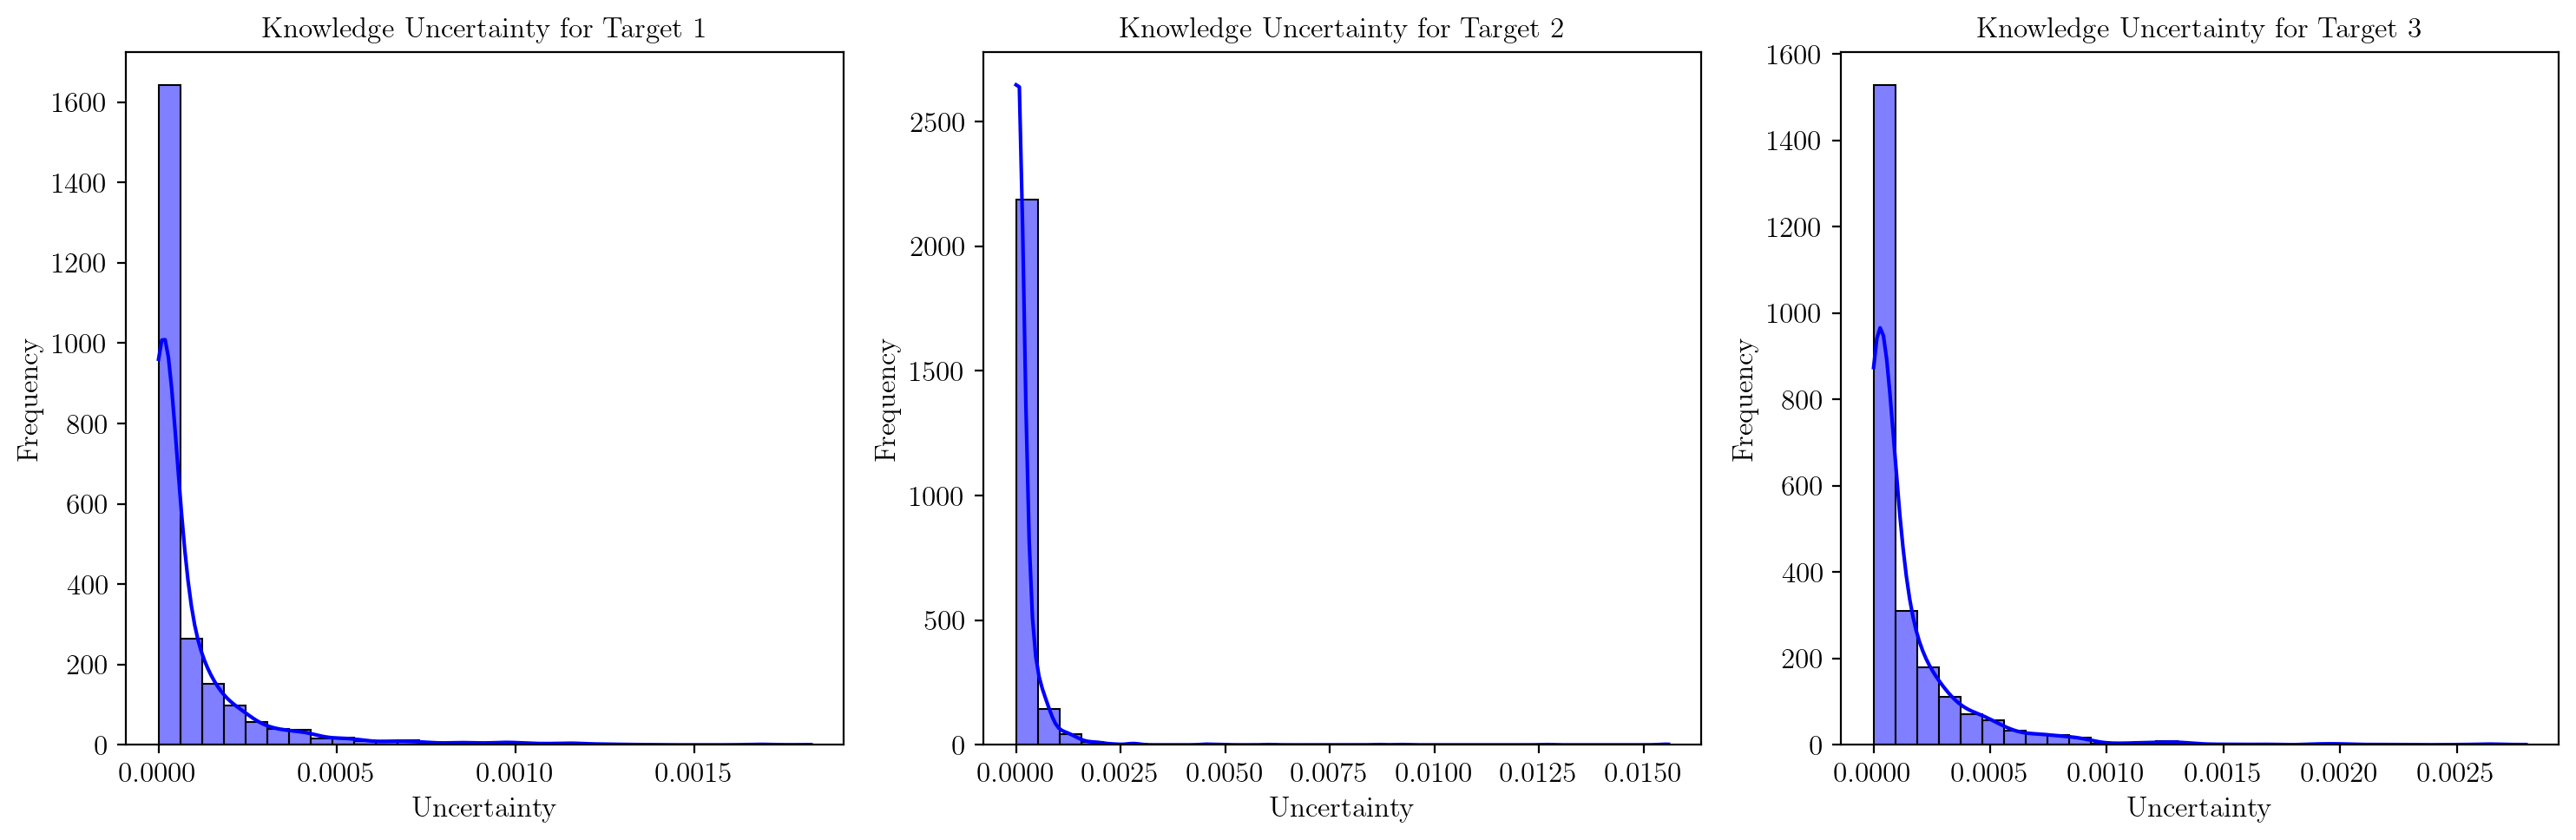

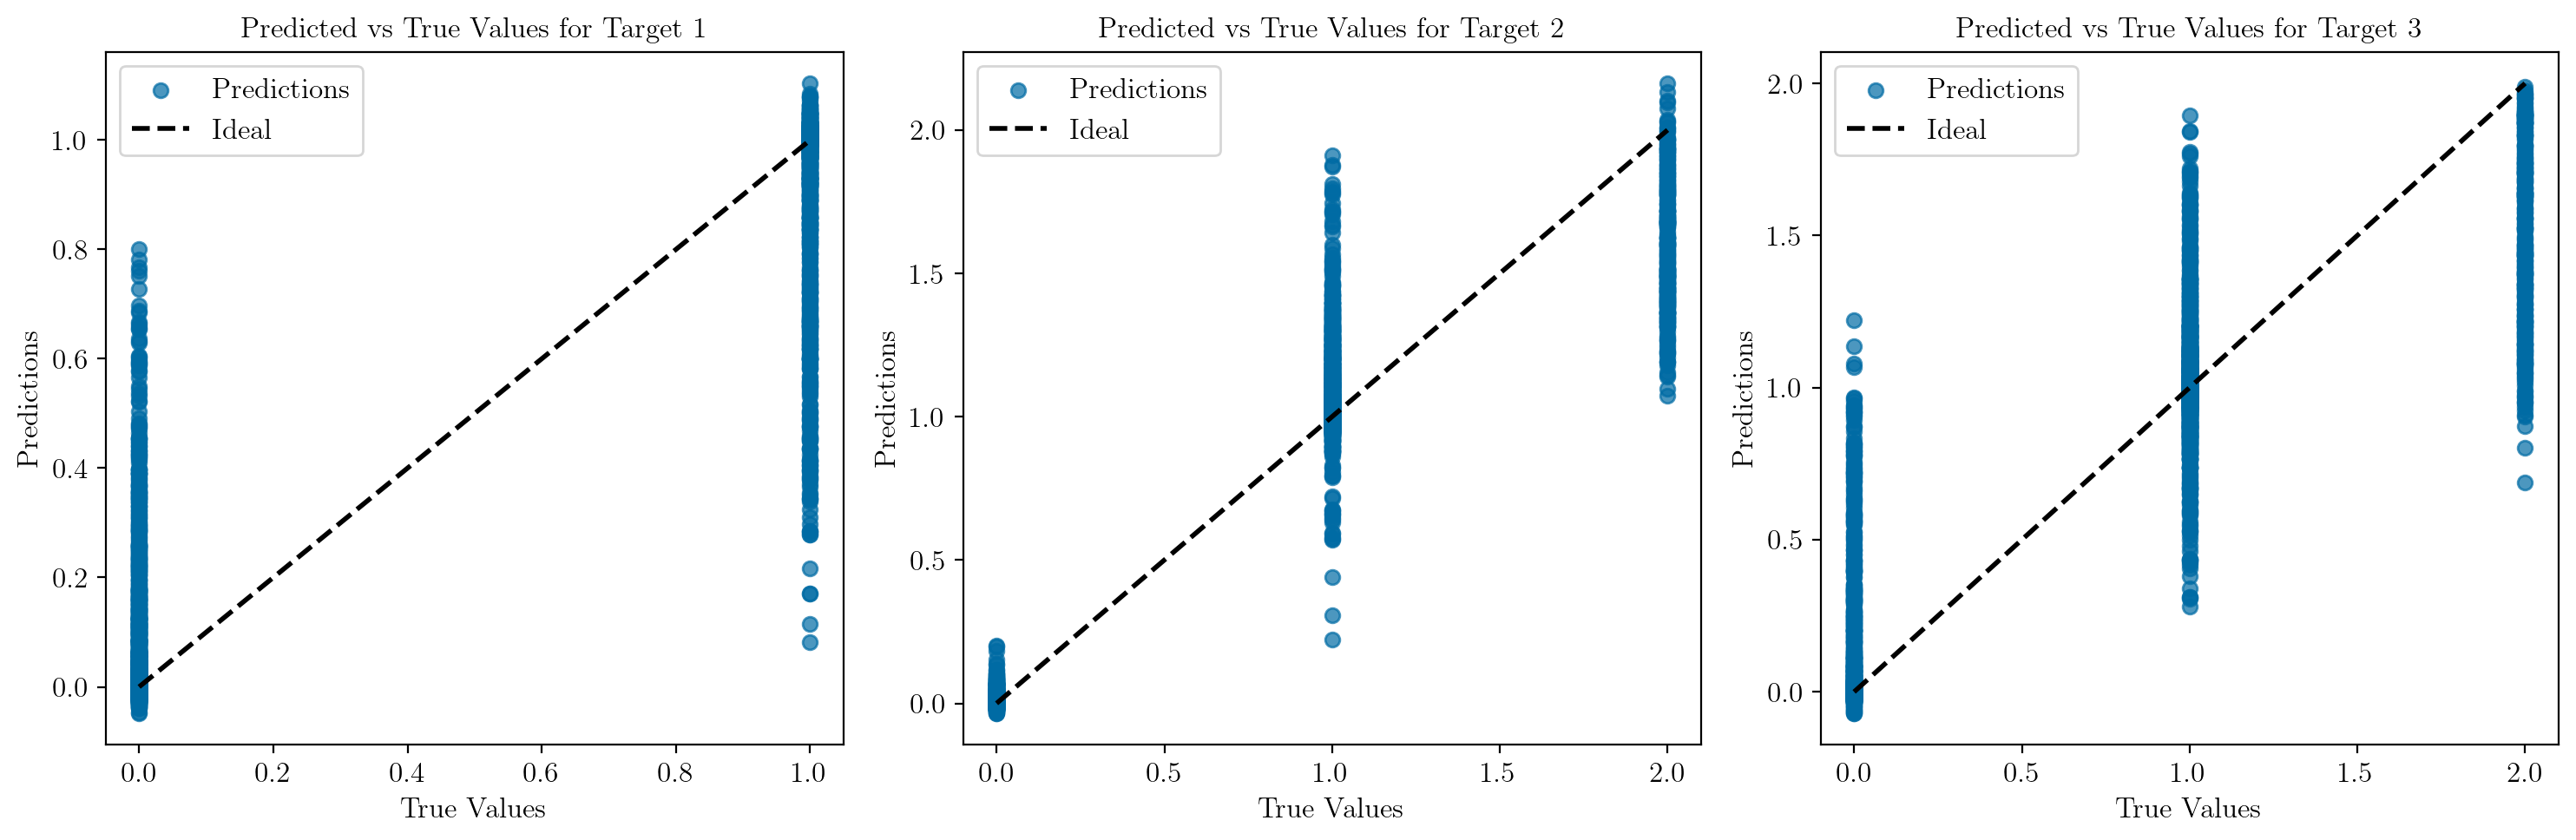

In [ ]:
plot_uncer(preds, y_test, data_uncertainty, knowledge_uncertainty)

# Uncer vs MSE

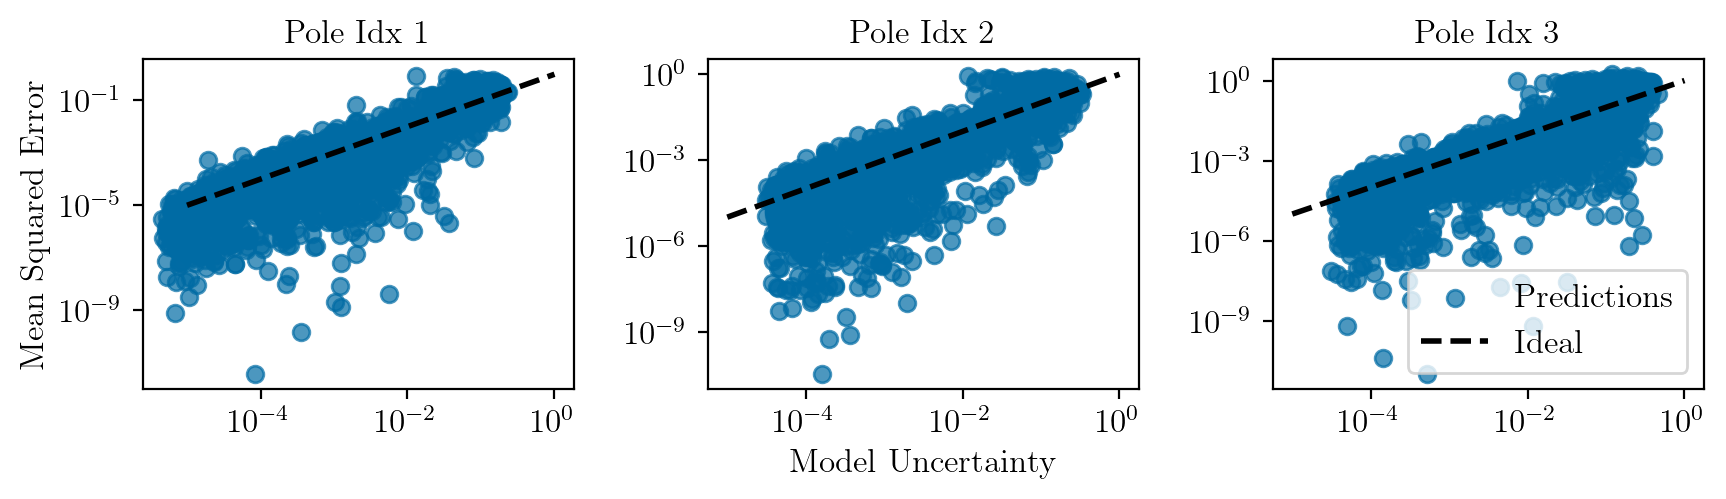

In [ ]:
plot_uncer_against_exact(preds, y_test, data_uncertainty)

# Accuracy

# Training Threshold

In [22]:
preds_train = []
data_uncertainty_train = []
knowledge_uncertainty_train = []

preds_test = []
data_uncertainty_test = []
knowledge_uncertainty_test = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train, y_train[:, i])
    val_pool = Pool(X_test, y_test[:, i])

    model = models[i]

    # Generate predictions with uncertainty
    pred_train = model.virtual_ensembles_predict(X_train, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_train.append(pred_train[:, 0])  # Mean predictions
    data_uncertainty_train.append(pred_train[:, 2])  # Data uncertainty
    knowledge_uncertainty_train.append(pred_train[:, 1])  # Knowledge uncertainty

    pred_test = model.virtual_ensembles_predict(X_test, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_test.append(pred_test[:, 0])  # Mean predictions
    data_uncertainty_test.append(pred_test[:, 2])  # Data uncertainty
    knowledge_uncertainty_test.append(pred_test[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds_train = np.column_stack(preds_train)
data_uncertainty_train = np.column_stack(data_uncertainty_train)
knowledge_uncertainty_train = np.column_stack(knowledge_uncertainty_train)

preds_test = np.column_stack(preds_test)
data_uncertainty_test = np.column_stack(data_uncertainty_test)
knowledge_uncertainty_test = np.column_stack(knowledge_uncertainty_test)

In [8]:
optimized_thresholds = optimize_thresholds(preds_train, y_train, class_to_poles)
print("Optimized Thresholds:", optimized_thresholds)

Optimization result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.8729629629629629
             x: [ 4.899e-01  4.893e-01  4.749e-01  5.188e-01  4.951e-01
                  5.284e-01  4.582e-01  5.924e-01]
           nit: 70
          nfev: 186
 final_simplex: (array([[ 4.899e-01,  4.893e-01, ...,  4.582e-01,
                         5.924e-01],
                       [ 4.899e-01,  4.893e-01, ...,  4.582e-01,
                         5.924e-01],
                       ...,
                       [ 4.899e-01,  4.893e-01, ...,  4.582e-01,
                         5.924e-01],
                       [ 4.899e-01,  4.893e-01, ...,  4.582e-01,
                         5.924e-01]]), array([-8.730e-01, -8.730e-01, -8.730e-01, -8.730e-01,
                       -8.730e-01, -8.730e-01, -8.730e-01, -8.730e-01,
                       -8.730e-01]))
Optimized Thresholds: [0.48985647 0.48926699 0.47491496 0.51878173 0.49506742 0.528423

In [9]:
adjusted_preds_train = round_with_thresholds(preds_train, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds_train) == y_train, axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds_train == y_train, axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Improved: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.8584
Test Accuracy Improved: 0.8730


In [14]:
adjusted_preds = round_with_thresholds(preds, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds) == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.8258
Test Accuracy: 0.8392


In [11]:
# Test Accuracy Baselie: 0.9281
# Test Accuracy Improved: 0.9326

# Test Accuracy Baselie: 0.8554
# Test Accuracy Improved: 0.8638

In [6]:


np.max(preds,axis=1)

array([1.01670796, 1.83625391, 1.02074891, ..., 1.42397099, 1.01789333,
       0.93248068])

# Removing

/tmp/ipykernel_104066/1589510332.py:22: RuntimeWarning: invalid value encountered in scalar divide
  acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]


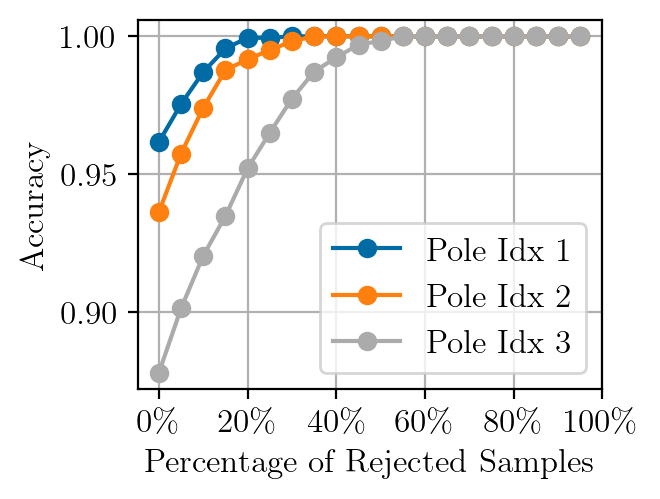

In [4]:
# Sort the data by uncertainty for each target
mse_changes = []
percent_removed = []

for i in range(y_train.shape[1]):
    sorted_indices = np.argsort(data_uncertainty[:, i])[::-1] 
    sorted_uncertainties = data_uncertainty[sorted_indices, i]
    sorted_true = y_test[sorted_indices, i]
    sorted_preds = preds[sorted_indices, i]

    # Calculate the MSE after removing samples with the highest uncertainty
    acc_list = []
    percent_list = []
    total_samples = len(sorted_uncertainties)

    for remove_percent in range(0, 101, 5):  # Remove in 5% increments
        num_remove = int(total_samples * (remove_percent / 100))
        remaining_true = sorted_true[num_remove:]
        remaining_preds = sorted_preds[num_remove:]

        # mse = np.mean((remaining_true - remaining_preds) ** 2)  # Calculate MSE
        acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]
        acc_list.append(acc)
        percent_list.append(remove_percent)
        

    mse_changes.append(acc_list)
    percent_removed.append(percent_list)

# Plot the results
# plt.figure(figsize=(15, 5))
fig, axs = plt.subplots(1,figsize=(3.54331, 3.54331*0.75))

for i in range(y_train.shape[1]):
    axs.plot(percent_removed[i], mse_changes[i],"-o", label=f"Pole Idx {i+1}")
axs.set_xlabel("Percentage of Rejected Samples")
axs.set_ylabel("Accuracy")
# axs.set_title("Impact of Removing High-Uncertainty Samples on Acc")
axs.legend()
axs.set_xticks([0, 20, 40, 60, 80, 100])
axs.set_xticklabels([f"{int(p)}\%" for p in [0, 20, 40, 60, 80, 100]])
axs.grid(True)
fig.tight_layout()
# fig.show()

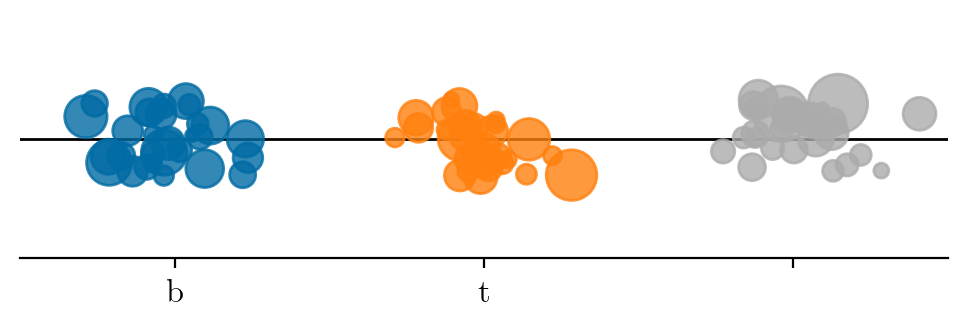

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Settings
np.random.seed(42)
n_per_group = 30
group_centers = [-1, 0, 1]
group_labels = ['b', 't', '']
colors = ['C0', 'C1', 'C2']

# Generate data
x_vals = []
y_vals = []
blob_sizes = []
blob_colors = []

for i, center in enumerate(group_centers):
    # Gaussian x around center
    x_group = np.random.normal(loc=center, scale=0.15, size=n_per_group)
    # Vertical jitter for separation (like seaborn stripplot)
    y_group = np.random.uniform(-0.05, 0.05, size=n_per_group)
    # size_group = np.random.uniform(30, 300, size=n_per_group)
    size_group = np.random.lognormal(mean=4.5, sigma=0.7, size=n_per_group)
    color_group = [colors[i]] * n_per_group

    x_vals.extend(x_group)
    y_vals.extend(y_group)
    blob_sizes.extend(size_group)
    blob_colors.extend(color_group)

# with plt.xkcd():
    # Plot
fig, ax = plt.subplots(figsize=(5, 1.8))

# Baseline line
ax.axhline(0, color='black', linewidth=1, zorder=0)

# Draw blobs
ax.scatter(x_vals, y_vals, s=blob_sizes, c=blob_colors, alpha=0.8)

# Ticks
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels)

# Style
ax.get_yaxis().set_visible(False)
for spine in ['left', 'right', 'top']:
    ax.spines[spine].set_visible(False)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-0.15, 0.15)

plt.tight_layout()
plt.show()


# Hist

In [ ]:
# Number of classes
num_classes = 8
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]
# Initialize an array to store accuracies for each class across folds
class_accuracies= []
class_uncer = []


for cls in range(num_classes):
    # Mask for the current class
    
    class_mask = (reconvert_labels(y_test, class_to_poles) == cls)
    # Calculate accuracy for the current fold and class
    # /np.sum(np.ones_like(y_test[:,0]))
    class_accuracy = np.sum(np.sum(adjusted_preds[class_mask]==y_test[class_mask],axis=1) == 3) / np.sum(class_mask)
    class_accuracies.append(class_accuracy)

    class_u = np.mean(data_uncertainty_test[class_mask])
    class_uncer.append(class_u)

class_accuracies = np.array(class_accuracies)
class_uncer = np.array(class_uncer)
# Bar plot with error bars
sorted_indices = np.argsort(class_accuracies)[::-1]
sorted_means = class_accuracies[sorted_indices]
sorted_stds = class_uncer[sorted_indices]
sorted_labels = [str(class_to_poles[i]) for i in sorted_indices]

# Plotting
fig, ax = plt.subplots(figsize=(3.54331, 3.54331*0.75))
ax.bar(range(num_classes), sorted_means, yerr=sorted_stds, capsize=5)
ax.set_ylabel('Accuracy')

ax.set_xticks(np.arange(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0,1)
# Adjust layout and show the plot
plt.tight_layout()
plt.show()

NameError: name 'class_to_poles' is not defined

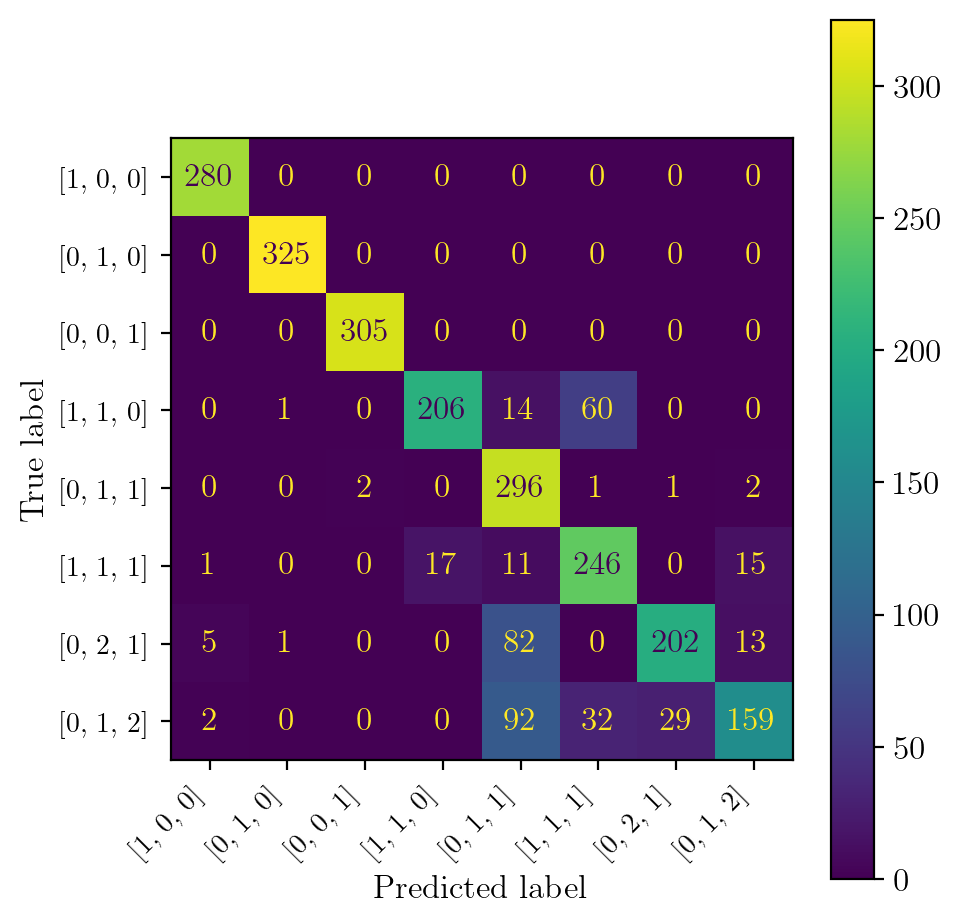

In [45]:
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Compute the confusion matrix
predictions = reconvert_labels(np.abs(np.round(preds)).tolist(), class_to_poles)
cm = confusion_matrix(reconvert_labels(y_test, class_to_poles), predictions, labels=np.arange(len(class_to_poles)))

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(5, 5))  # Adjust figure size if needed
disp.plot(ax=ax)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()

# Anomaly detection

In [ ]:
# ext_old_label_arr = np.array([np.tile(i,np.load(f"{'dataExt/P'}{0:02d}{'_intensity.pkl'}", allow_pickle=True).shape[0]) for i in np.arange(35)]).flatten()
# ext_class_to_poles = {
#     0: [0, 0, 0],  # 1 pole on [bt]
#     1: [1, 0, 0],  # 1 pole on [bb]
#     2: [0, 1, 0],  # 1 pole on [tb]
#     3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
#     4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
#     5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
#     6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
#     7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
#     8: [1, 0, 1],
#     9: [0, 1, 1],
#     10: [3, 0, 0],
#     11: [0, 3, 0],
#     12: [0, 0, 3],
#     13: [2, 1, 0],
#     14: [2, 0, 1],
#     15: [1, 2, 0],
#     16: [0, 2, 1],
#     17: [1, 0, 2],
#     18: [0, 1, 2],
#     19: [1, 1, 1],
#     20: [4, 0, 0],
#     21: [0, 4, 0],
#     22: [0, 0, 4],
#     23: [3, 1, 0],
#     24: [3, 0, 1],
#     25: [1, 3, 0],
#     26: [0, 3, 1],
#     27: [1, 0, 3],
#     28: [0, 1, 3],
#     29: [2, 2, 0],
#     30: [2, 0, 2],
#     31: [0, 2, 2],
#     32: [2, 1, 1],
#     33: [1, 2, 1],
#     34: [1, 1, 2],
# }



# ext_label_arr = convert_labels(ext_old_label_arr, ext_class_to_poles)
# ext_features_memmap = np.load('dataExt/features_filtered.npy', mmap_mode='r+')

In [ ]:
# ext_X_outside = ext_features_memmap[np.where((ext_label_arr == [2,0,0]).all(axis=1))[0]]
# ext_y_outside = ext_label_arr[np.where((ext_label_arr == [2,0,0]).all(axis=1))[0]]

# ext_X_inside = features_memmap[np.where((new_label_arr == [1,0,0]).all(axis=1))[0]]
# ext_y_inside = new_label_arr[np.where((new_label_arr == [1,0,0]).all(axis=1))[0]]

In [ ]:
# extented_preds_outside = []
# extented_data_uncertainty_outside = []
# extented_knowledge_uncertainty_outside = []

# extented_preds_inside = []
# extented_data_uncertainty_inside = []
# extented_knowledge_uncertainty_inside = []

# for i in range(y_train.shape[1]):
    
#     model = models[i]

#     # Generate predictions with uncertainty
#     pred_outside = model.virtual_ensembles_predict(ext_X_outside, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     extented_preds_outside.append(pred_outside[:, 0])  # Mean predictions
#     extented_data_uncertainty_outside.append(pred_outside[:, 2])  # Data uncertainty
#     extented_knowledge_uncertainty_outside.append(pred_outside[:, 1])  # Knowledge uncertainty

#         # Generate predictions with uncertainty
#     pred_inside = model.virtual_ensembles_predict(ext_X_inside, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     extented_preds_inside.append(pred_inside[:, 0])  # Mean predictions
#     extented_data_uncertainty_inside.append(pred_inside[:, 2])  # Data uncertainty
#     extented_knowledge_uncertainty_inside.append(pred_inside[:, 1])  # Knowledge uncertainty

# # Convert lists to arrays for easier manipulation
# extented_preds_outside = np.column_stack(extented_preds_outside)
# extented_data_uncertainty_outside = np.column_stack(extented_data_uncertainty_outside)
# extented_knowledge_uncertainty_outside = np.column_stack(extented_knowledge_uncertainty_outside)

# # Convert lists to arrays for easier manipulation
# extented_preds_inside = np.column_stack(extented_preds_inside)
# extented_data_uncertainty_inside = np.column_stack(extented_data_uncertainty_inside)
# extented_knowledge_uncertainty_inside = np.column_stack(extented_knowledge_uncertainty_inside)

In [3]:
# # Define a shared bin range
# bins = np.linspace(
#     min(extented_data_uncertainty_outside.min(), extented_data_uncertainty_inside.min(),
#         extented_knowledge_uncertainty_outside.min(), extented_knowledge_uncertainty_inside.min()),
#     max(extented_data_uncertainty_outside.max(), extented_data_uncertainty_inside.max(),
#         extented_knowledge_uncertainty_outside.max(), extented_knowledge_uncertainty_inside.max()),
#     50
# )

# # Plot Data Uncertainty
# plt.figure(figsize=(15/2, 5/2))
# for i in range(y_train.shape[1]):
#     plt.subplot(1, 3, i + 1)
#     sns.histplot(extented_data_uncertainty_outside[:, i], kde=False, bins=bins, color='red', label="Outside", alpha=0.6)
#     sns.histplot(extented_data_uncertainty_inside[:, i], kde=False, bins=bins, color='blue', label="Inside", alpha=0.6)
#     plt.title(f"Data Uncertainty for Target {i+1}")
#     plt.xlabel("Uncertainty")
#     plt.ylabel("Frequency")
#     # if i == 0:  # Add legend to the first subplot only
#     #     plt.legend(title="Source")
# plt.tight_layout()
# plt.show()

# # Plot Knowledge Uncertainty
# plt.figure(figsize=(15/2, 5/2))
# for i in range(y_train.shape[1]):
#     plt.subplot(1, 3, i + 1)
#     sns.histplot(extented_knowledge_uncertainty_outside[:, i], kde=False, bins=bins, color='red', label="Outside", alpha=0.6)
#     sns.histplot(extented_knowledge_uncertainty_inside[:, i], kde=False, bins=bins, color='blue', label="Inside", alpha=0.6)
#     plt.title(f"Knowledge Uncertainty for Target {i+1}")
#     plt.xlabel("Uncertainty")
#     plt.ylabel("Frequency")
#     if i == 0:  # Add legend to the first subplot only
#         plt.legend(title="Source")
# plt.tight_layout()
# plt.show()
